In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
DATA_PATH = "../data/processed/news_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (44898, 6)


In [3]:
df.head()

,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (44898, 6)

Columns:
['title', 'text', 'subject', 'date', 'label', 'content']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
 5   content  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


In [6]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

In [7]:
df.describe(include="all")

,title,text,subject,date,label,content
count,44898,44898,44898,44898,44898.000000,44898
unique,38729,38646,8,2397,NaN,39105
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN,Highlights: The Trump presidency on April 13 a...
freq,14,627,11272,182,NaN,8
mean,NaN,NaN,NaN,NaN,0.477015,NaN
std,NaN,NaN,NaN,NaN,0.499477,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,NaN,1.000000,NaN


In [10]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 209


In [12]:
# Remove duplicate rows

print("Dataset shape before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape before removing duplicates: (44898, 6)
Dataset shape after removing duplicates: (44689, 6)
Remaining duplicate rows: 0


In [ ]:
##0 → Fake News
##1 → Real News

In [8]:
# Class distribution
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

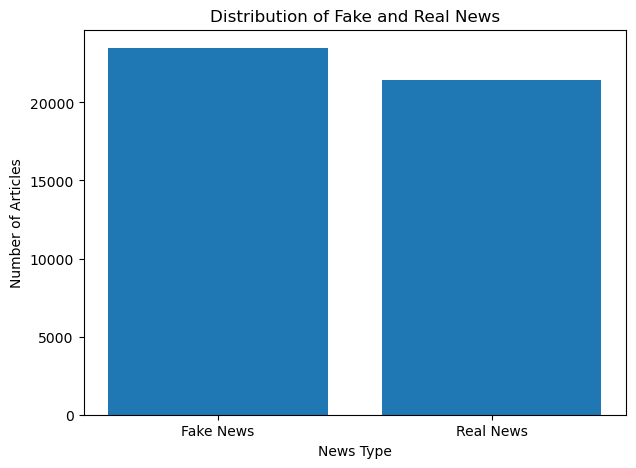

In [9]:
# Convert labels to readable names for visualization
label_counts = df["label"].map({
    0: "Fake News",
    1: "Real News"
}).value_counts()

# Plot class distribution
plt.figure(figsize=(7, 5))

plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

### Interpretation

The dataset contains 23,481 fake news articles and 21,417 real news articles. The distribution between the two classes is relatively balanced, with only a small difference in the number of samples. Therefore, severe class imbalance is not expected to significantly affect the fake news classification model.

In [13]:
# Check the unique subjects

print("Unique Subjects:")

print(df["subject"].unique())

Unique Subjects:
['US_News' 'politicsNews' 'News' 'Government News' 'left-news' 'worldnews'
 'politics' 'Middle-east']


In [14]:
# Count articles in each subject

subject_counts = df["subject"].value_counts()

subject_counts

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

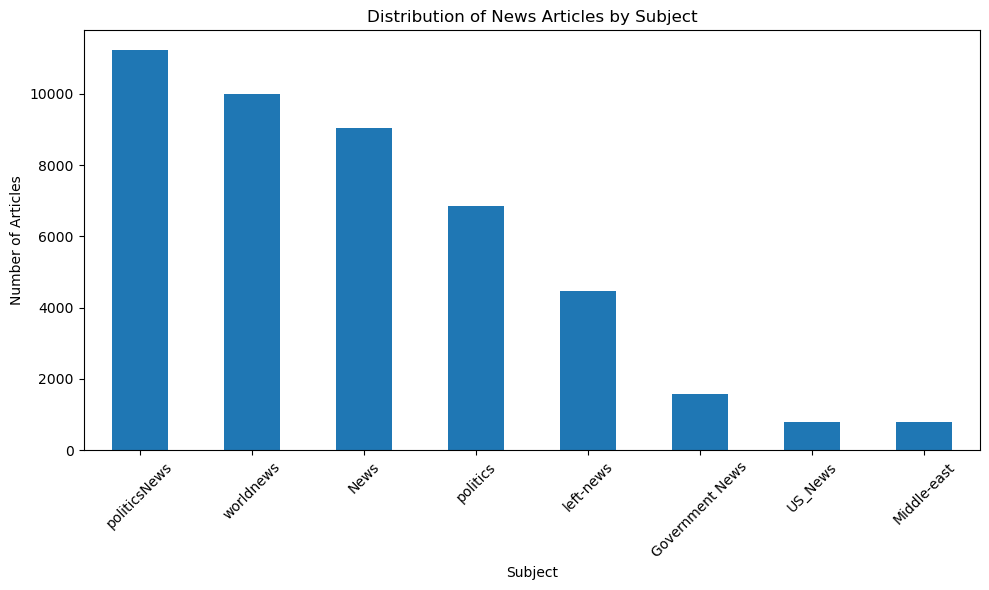

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

subject_counts.plot(
    kind="bar"
)

plt.title("Distribution of News Articles by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Fake vs Real News Distribution by Subject

In [16]:
# Create a cross-tabulation of subject and label

subject_label_counts = pd.crosstab(
    df["subject"],
    df["label"]
)

# Rename columns for better readability

subject_label_counts.columns = [
    "Fake News",
    "Real News"
]

subject_label_counts

,Fake News,Real News
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6838,0
politicsNews,0,11220
worldnews,0,9991


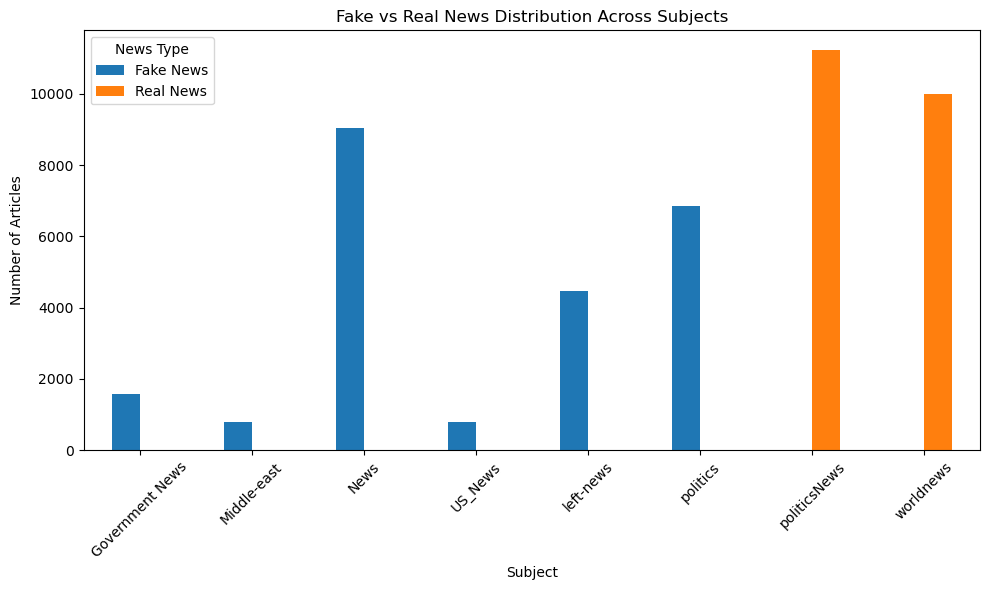

In [17]:
subject_label_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Fake vs Real News Distribution Across Subjects")
plt.xlabel("Subject")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.legend(title="News Type")

plt.tight_layout()

plt.show()

## Article Length Analysis

In [18]:
# Create article length features

df["text_length"] = df["content"].str.len()

df["word_count"] = df["content"].str.split().str.len()

# Display summary statistics

df[["text_length", "word_count"]].describe()

,text_length,word_count
count,44689.000000,44689.000000
mean,2548.274005,417.429748
std,2174.594406,351.792113
min,31.000000,2.000000
25%,1314.000000,215.000000
50%,2268.000000,374.000000
75%,3186.000000,525.000000
max,51893.000000,8148.000000


In [19]:
# Compare average article length by label

length_comparison = df.groupby("label")[
    ["text_length", "word_count"]
].mean()

# Rename labels

length_comparison.index = ["Fake News", "Real News"]

length_comparison

,text_length,word_count
Fake News,2642.749936,437.956555
Real News,2443.700627,394.709066


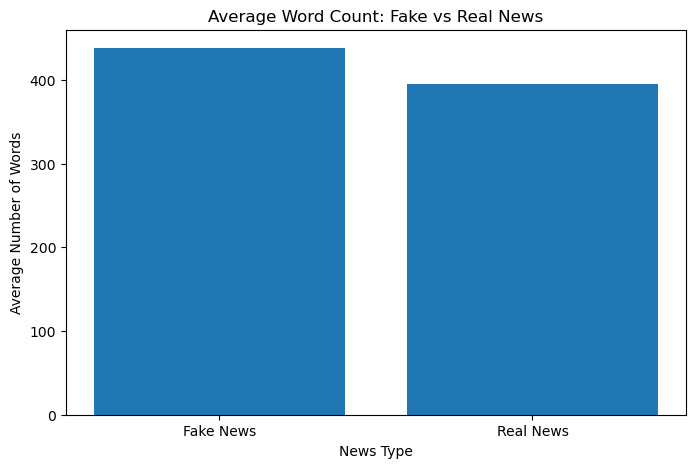

In [20]:
# Plot average word count for Fake vs Real News

plt.figure(figsize=(8, 5))

plt.bar(
    length_comparison.index,
    length_comparison["word_count"]
)

plt.title("Average Word Count: Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Average Number of Words")

plt.show()

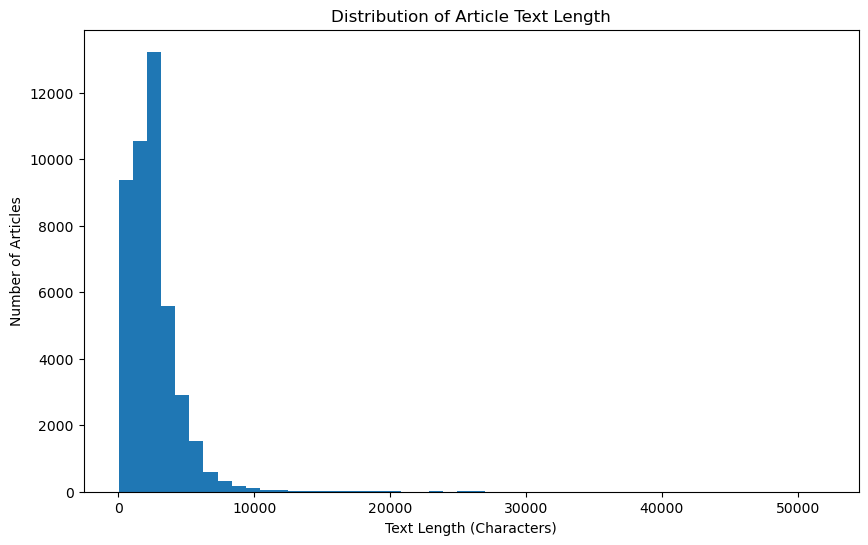

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Distribution of Article Text Length")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Number of Articles")

plt.show()

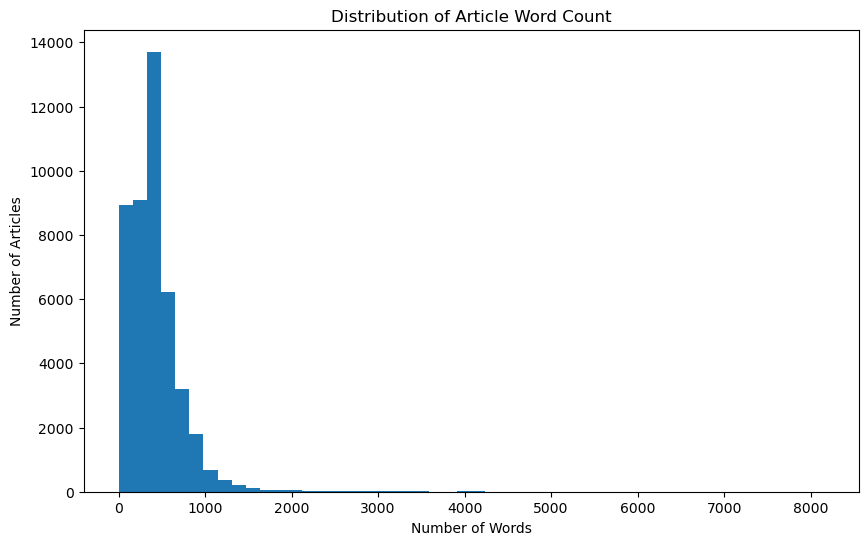

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Article Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

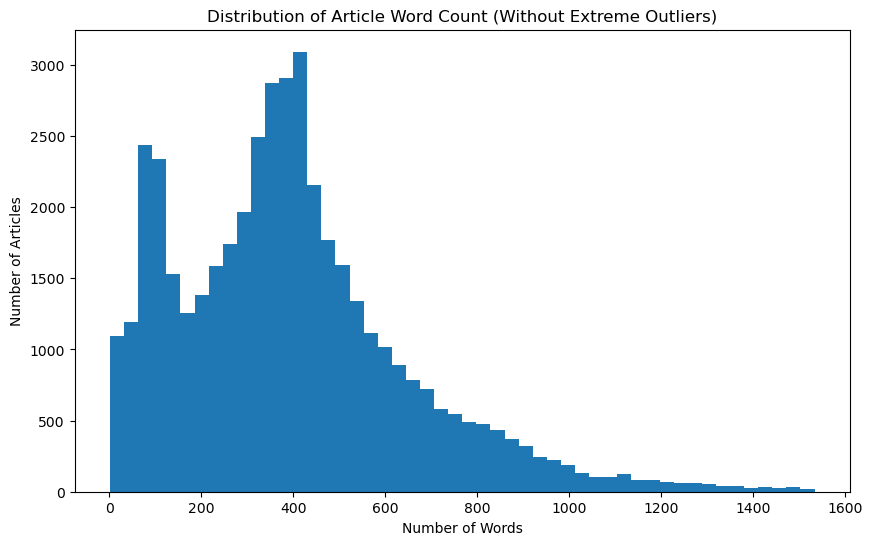

In [23]:
# Calculate the 99th percentile
limit = df["word_count"].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    df[df["word_count"] <= limit]["word_count"],
    bins=50
)

plt.title("Distribution of Article Word Count (Without Extreme Outliers)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")

plt.show()

In [24]:
# Check for empty content

empty_content = df["content"].str.strip().eq("").sum()

print("Number of empty content rows:", empty_content)

Number of empty content rows: 0


In [25]:
import re

# Create a copy of the original content
df["clean_content"] = df["content"].copy()

# Convert text to lowercase
df["clean_content"] = df["clean_content"].str.lower()

# Remove URLs
df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

# Remove extra spaces
df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

print("Text cleaning completed successfully!")

Text cleaning completed successfully!


In [26]:
# Remove punctuation and special characters

df["clean_content"] = df["clean_content"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

print("Punctuation and special characters removed successfully!")

Punctuation and special characters removed successfully!


## Stopword Removal


In [27]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [28]:
# Remove stopwords

stop_words = set(ENGLISH_STOP_WORDS)

df["clean_content"] = df["clean_content"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

print("Stopwords removed successfully!")

Stopwords removed successfully!


In [29]:
df[["content", "clean_content"]].head(3)

,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls th circuit court committed cou...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon national security cou...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects lift jones act shipping re...


In [30]:
# Create title length feature

df["title_length"] = df["title"].str.len()

df[["title", "title_length"]].head()

,title,title_length
0,Ben Stein Calls Out 9th Circuit Court: Committ...,89
1,Trump drops Steve Bannon from National Securit...,55
2,Puerto Rico expects U.S. to lift Jones Act shi...,64
3,OOPS: Trump Just Accidentally Confirmed He Le...,89
4,Donald Trump heads for Scotland to reopen a go...,55


In [31]:
import os

# Create processed folder
os.makedirs("../data/processed", exist_ok=True)

# Save the preprocessed dataset
df.to_csv(
    "../data/processed/preprocessed_news.csv",
    index=False
)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!
